First Importing All The Necesary Dependencies

In [44]:
import os
import xml.etree.ElementTree as ET
from collections import Counter 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

In [45]:
Dataset_Folder = r"C:\Users\kiran\Downloads\Military-Camouflage-MHCD2022\Military-Camouflage-MHCD2022"
Images_Path = os.path.join(Dataset_Folder, "JPEGImages")
Annotations_Path = os.path.join(Dataset_Folder, "Annotations")



In [46]:
images = os.listdir(Images_Path)
annotations = os.listdir(Annotations_Path)

print(f"Total Images : {len(images)}")
print(f"Total Annotations : {len(annotations)}")

Total Images : 3000
Total Annotations : 3000


In [47]:
widths = []
heights = [] 

for img_name in tqdm(images):
    img_path = os.path.join(Images_Path, img_name)
    img = Image.open(img_path)
    width, height = img.size
    widths.append(width)
    heights.append(height)

100%|██████████| 3000/3000 [00:00<00:00, 10050.90it/s]


In [48]:
print(f"Average Width : {np.mean(widths)}")
print(f"Average Height : {np.mean(heights)}")

print(f"Minimum Width : {np.min(widths)}")
print(f"Minimum Height : {np.min(heights)}")

print(f"Maximum Width : {np.max(widths)}")
print(f"Maximum Height : {np.max(heights)}")

Average Width : 714.098
Average Height : 434.3403333333333
Minimum Width : 200
Minimum Height : 146
Maximum Width : 2810
Maximum Height : 1880


<Figure size 1200x500 with 0 Axes>

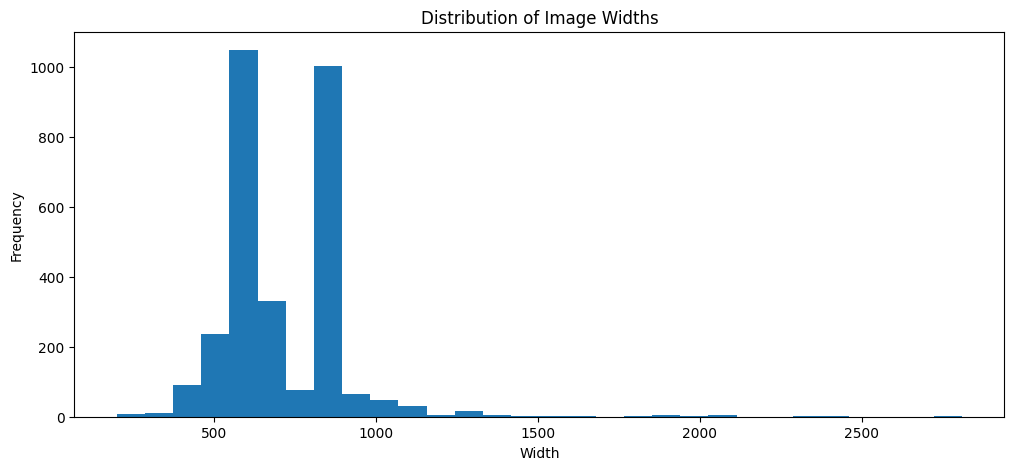

<Figure size 1200x500 with 0 Axes>

In [49]:
plt.figure(figsize=(12, 5))
plt.hist(widths, bins=30)
plt.title("Distribution of Image Widths")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.figure(figsize=(12, 5))

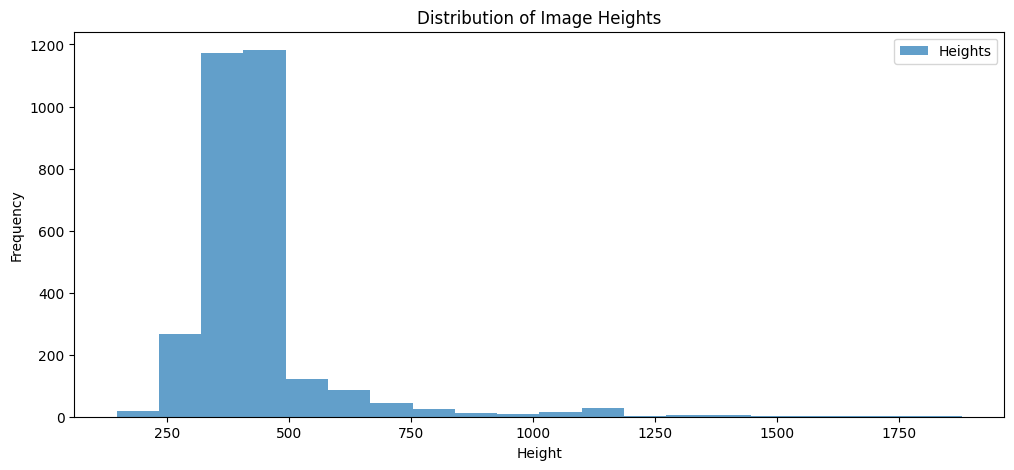

In [50]:
plt.figure(figsize=(12, 5))
plt.hist(heights, bins=20, alpha=0.7, label='Heights')
plt.title("Distribution of Image Heights")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.legend()
plt.show()

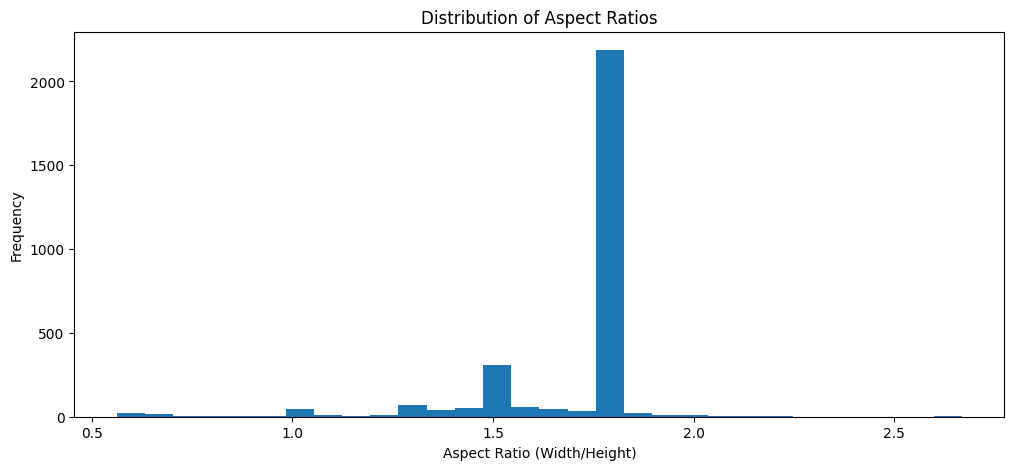

In [51]:
aspect_ratios=[]
for w, h in zip(widths, heights):
    aspect_ratios.append(w/h)

plt.figure(figsize=(12, 5))
plt.hist(aspect_ratios, bins=30)
plt.title("Distribution of Aspect Ratios")
plt.xlabel("Aspect Ratio (Width/Height)")
plt.ylabel("Frequency")
plt.show() 


In [52]:
class_counts = Counter()

all_boxes =[]

for xml_files in tqdm(annotations):
    xml_path = os.path.join(Annotations_Path, xml_files)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        class_counts[class_name] += 1
        
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)
        
        all_boxes.append((class_name, xmin, ymin, xmax, ymax))

100%|██████████| 3000/3000 [00:00<00:00, 15399.25it/s]
